In [58]:
import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

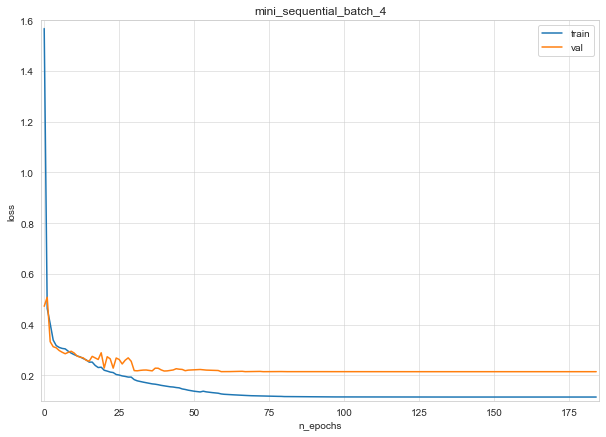

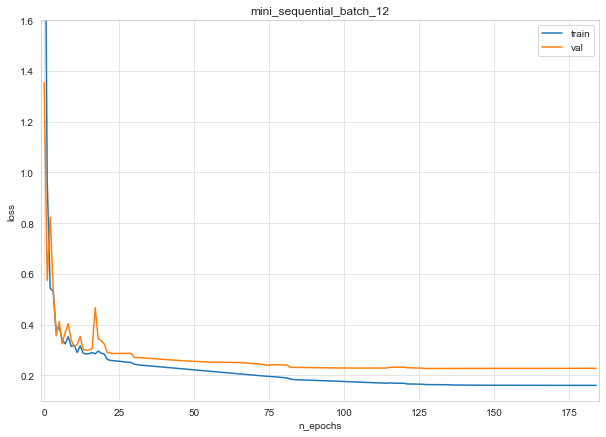

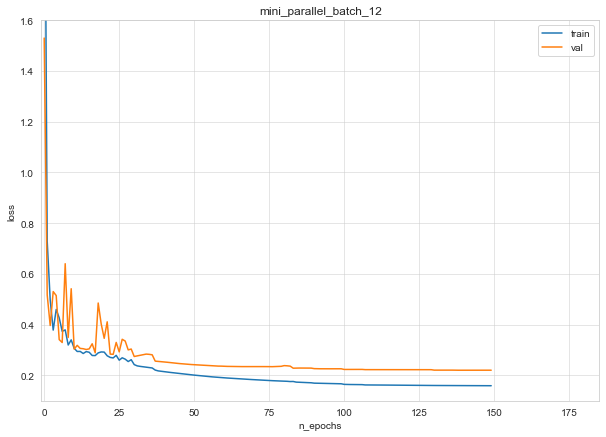

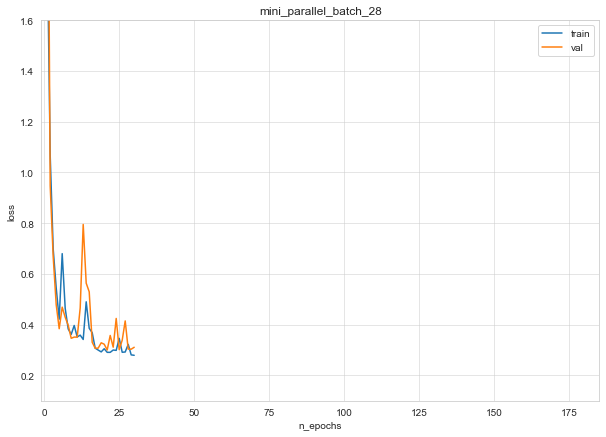

In [35]:
names = ["mini_sequential_batch_4", "mini_sequential_batch_12", "mini_parallel_batch_12", "mini_parallel_batch_28"]
num_epochs = 185
for name in names:
    #with open('training-{0}-batch-{1}.log'.format(name, str(batch_size)),'rb') as f:
    history = pd.read_csv('../training_{0}/training.log'.format(name, name))
    plt.figure(figsize=(10,7))
    ax = plt.subplot()
    plt.plot(history['train_loss'],label = 'train')
    plt.plot(history['val_loss'],label = 'val')
    plt.legend()
    plt.title(name)
    plt.xlabel('n_epochs')
    ax.set_ylim(0.1,1.6)
    ax.set_xlim(-1,num_epochs)
    plt.ylabel('loss')
    plt.grid(linewidth = 0.5)
    plt.savefig('{0}_loss.png'.format(name),dpi=400)

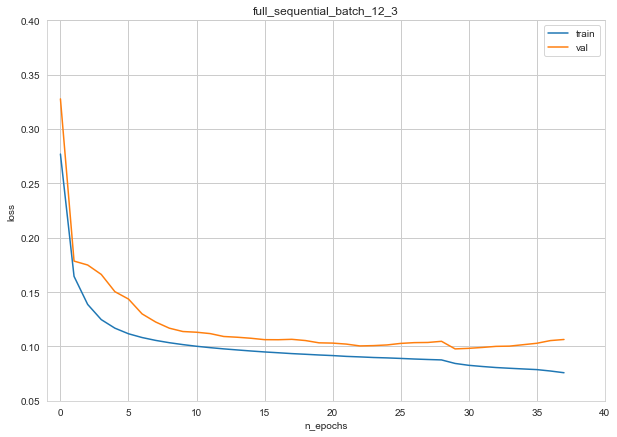

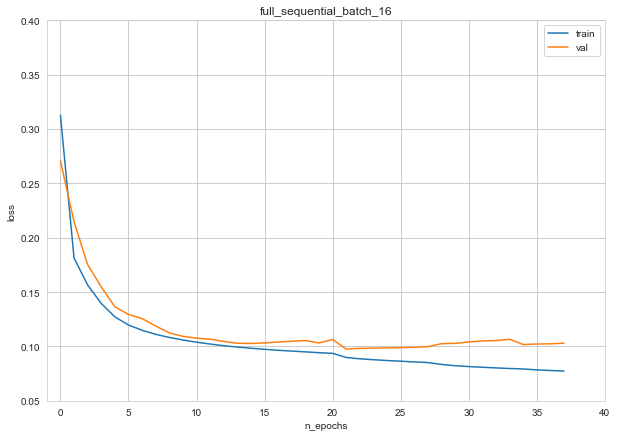

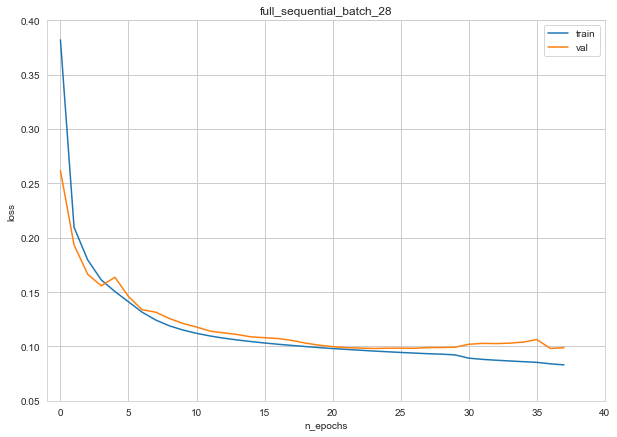

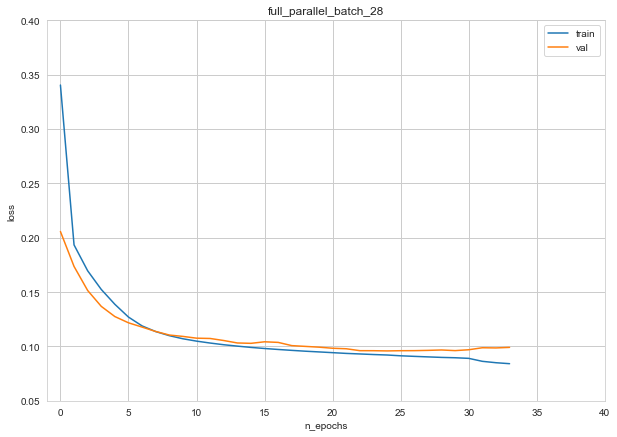

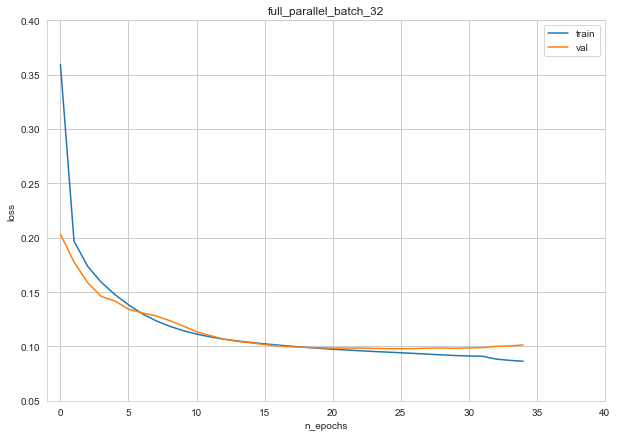

In [39]:
names = ["full_sequential_batch_12_3", "full_sequential_batch_16", "full_sequential_batch_28", "full_parallel_batch_28", "full_parallel_batch_32"]
num_epochs = 40
for name in names:
    #with open('training-{0}-batch-{1}.log'.format(name, str(batch_size)),'rb') as f:
    history = pd.read_csv('../training_{0}/training.log'.format(name, name))
    plt.figure(figsize=(10,7))
    ax = plt.subplot()
    plt.plot(history['train_loss'],label = 'train')
    plt.plot(history['val_loss'],label = 'val')
    plt.legend()
    plt.title(name)
    plt.xlabel('n_epochs')
    #ax.set_ylim(0.1,1.6)
    ax.set_ylim(0.05,0.4)
    ax.set_xlim(-1,num_epochs)
    plt.ylabel('loss')
    plt.grid(linewidth = 1)
    plt.savefig('{0}_loss.png'.format(name),dpi=400)

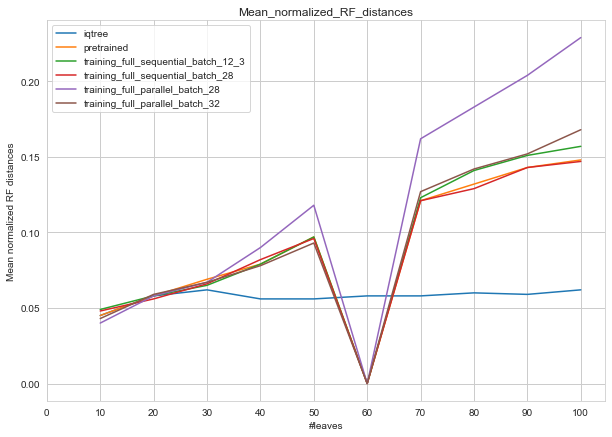

In [68]:
names = ["iqtree", "pretrained", "training_full_sequential_batch_12_3", "training_full_sequential_batch_28", "training_full_parallel_batch_28", "training_full_parallel_batch_32"]
num_leave_categories = 10
plt.figure(figsize=(10,7))
ax = plt.subplot()

for name in names:
    mean_RF_distances = []
    with open('../{0}/console_evaluate.log'.format(name)) as file:
        for line in file:
            RF_distance = float(line.rstrip().replace('Mean normalized Robinson-Foulds distance between true and predicted trees: ', ''))
            mean_RF_distances.append(RF_distance)
    if (len(mean_RF_distances) != num_leave_categories):
        print('Error: mean_RF_distances {}!'.format(len(mean_RF_distances)))
    plt.plot(mean_RF_distances,label = name)
plt.legend()
plt.title('Mean_normalized_RF_distances')
plt.xlabel('#leaves')
#ax.set_ylim(0.05,0.4)
#ax.set_xlim(0,num_epochs)
plt.xticks(np.arange(-1,10),np.arange(0, 110, 10))
plt.ylabel('Mean normalized RF distances')
plt.grid(linewidth = 1)
plt.savefig('Mean_normalized_RF_distances.png',dpi=400)

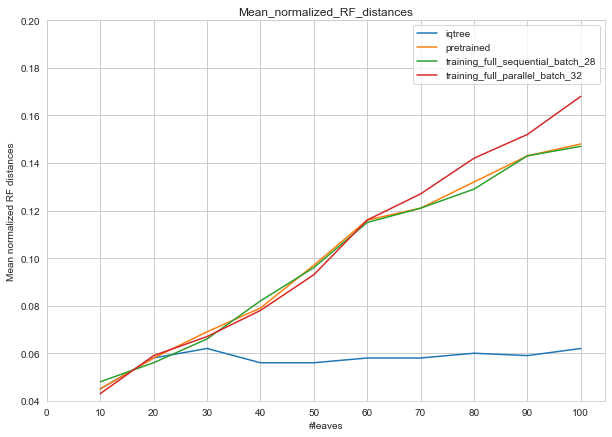

In [70]:
names = ["iqtree", "pretrained", "training_full_sequential_batch_28", "training_full_parallel_batch_32"]
num_leave_categories = 10
plt.figure(figsize=(10,7))
ax = plt.subplot()

for name in names:
    mean_RF_distances = []
    with open('../{0}/console_evaluate.log'.format(name)) as file:
        for line in file:
            RF_distance = float(line.rstrip().replace('Mean normalized Robinson-Foulds distance between true and predicted trees: ', ''))
            mean_RF_distances.append(RF_distance)
    if (len(mean_RF_distances) != num_leave_categories):
        print('Error: mean_RF_distances {}!'.format(len(mean_RF_distances)))
    plt.plot(mean_RF_distances,label = name)
plt.legend()
plt.title('Mean_normalized_RF_distances')
plt.xlabel('#leaves')
#ax.set_ylim(0.05,0.4)
#ax.set_xlim(0,num_epochs)
ax.set_ylim(0.04,0.2)
plt.xticks(np.arange(-1,10),np.arange(0, 110, 10))
plt.ylabel('Mean normalized RF distances')
plt.grid(linewidth = 1)
plt.savefig('Mean_normalized_RF_distances.png',dpi=400)

In [67]:
import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tensorflow import keras
import tensorflow as tf
import itertools
from joblib import parallel, delayed
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from tqdm import tqdm
from sklearn.model_selection import learning_curve
import itertools
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'tensorflow'

there are 5^4 - 1 = 624 patterns  (in reality there's also ---- ???)

let , f(A) = 0, f(C) = 1, f(G) = 2, f(T) = 3, f(-) =4

then for a site pattern p (n1,n2,n3,n4):

    the pattern index for p is f(n1) * 5^3  + f(n2) * 5^2 + f(n3) * 5 + f(n4)


In [11]:
num2nuc = {0:'A',1:'C',2:'G',3:'T',4:'-'}
def get_pattern(i):
    n1  = i // 125
    r = i % 125
    n2 = r // 25
    r = r % 25
    n3 = r // 5
    n4 = r % 5
    return ''.join([num2nuc[n]+'\n' for n in [n1,n2,n3,n4]])


In [12]:
tops = ['AB','AC','AD']
species = ['A','B','C','D']
def revert_label(i, top):
    order = P4[i]
    sib1 = order[tops.index(top)+1]
    sib2 = order[0]
    if 0 in (sib2,sib1):
        topr = sorted(species[sib1]+species[sib2])
    else:
        topr = sorted(''.join(species[num] for num in range(4) if num not in (sib2,sib1)))
    return topr


In [5]:
feature_names = []

for i in range(625):
    feature_names.append(get_pattern(i))




In [13]:
P4 = list(itertools.permutations([0,1,2,3]))

In [6]:
P4

[(0, 1, 2, 3),
 (0, 1, 3, 2),
 (0, 2, 1, 3),
 (0, 2, 3, 1),
 (0, 3, 1, 2),
 (0, 3, 2, 1),
 (1, 0, 2, 3),
 (1, 0, 3, 2),
 (1, 2, 0, 3),
 (1, 2, 3, 0),
 (1, 3, 0, 2),
 (1, 3, 2, 0),
 (2, 0, 1, 3),
 (2, 0, 3, 1),
 (2, 1, 0, 3),
 (2, 1, 3, 0),
 (2, 3, 0, 1),
 (2, 3, 1, 0),
 (3, 0, 1, 2),
 (3, 0, 2, 1),
 (3, 1, 0, 2),
 (3, 1, 2, 0),
 (3, 2, 0, 1),
 (3, 2, 1, 0)]

In [72]:
plt.rcParams['font.size'] = 20
plt.rcParams['figure.figsize'] = [12,8]
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['lines.markersize'] = 3

In [5]:
def feature_profile_multi(coeffs, feature_names, n_features=10,c = 'tab:blue',save_path=None,ylabel = 'Coefficient (Absolute value)',absolute=True,class_labels=None):
    for i in range(coeffs.shape[0]):
        fs = sorted(list(zip(coeffs[i].tolist(),feature_names)),reverse=True,key = lambda t: abs(t[0]))[:n_features]
        plt.figure()
        plt.grid()
        vals =  [abs(t[0]) for t in fs] if absolute else  [t[0] for t in fs]
        plt.bar(range(n_features), vals, tick_label = [t[1] for t in fs], color=c)
        plt.ylabel('Class {} '.format(i if class_labels==None else class_labels[i]) +ylabel)
        plt.xlabel('Feature')


        if save_path != None:
            plt.savefig(save_path + '_p_{}.png'.format(i),dpi=500)
    plt.show()

In [6]:
with open('./data_input/true_topologies.pk','rb') as f:
    true_topologies = pickle.load(f)

In [7]:
P4 = list(itertools.permutations([0,1,2,3]))
def read_msa(tree_i):
    msa_file = './data_input/alignments/t_{}.phy'.format(tree_i)
    with open(msa_file, 'r') as f:
        msa = f.readlines()[1:]
    msa.sort() # make the sequences ABCD
    msa = [s[1:].strip() for s in msa] # indices of sequences: 0,1,2,3, correspode to A,B,C,D
    topology = true_topologies[tree_i]
    sib_of_0 = ord(topology[-1]) - 65
    data = []
    for permu in P4:
        if permu[0] == 0:
            # A stay in the same place, find its sibling
            new_top = 'A'+chr(permu.index(sib_of_0) + 65)
        elif permu[0] == sib_of_0:
            # sibling becomes new A, find the old A
            new_top = 'A'+chr(permu.index(0) + 65)
        else:
            # neither of the sibling is the new A
            new_top = 'A'+chr(permu.index([t for t in range(1,4) if t!= permu[0] and t!= sib_of_0][0]) + 65)
        new_msa = [msa[i] for i in permu]
        data.append((new_msa,new_top))
    return data



def encode_msa(msa):
    s_length = len(msa[0])
    pattern_counts = np.zeros(625, dtype=int)
    n_map = {'A':0,'C':1,'G':2,'T':3,'-':4}
    for i in range(s_length):
        n1,n2,n3,n4 = [s[i] for s in msa]
        pattern_counts[n_map[n1] * 125 + n_map[n2] * 25 + n_map[n3] *5 + n_map[n4]] += 1

    assert(pattern_counts.sum() == s_length)
    return pattern_counts



In [9]:
msa_encoded = []
true_labels = []
for i in tqdm(range(110000)):
    data = read_msa(i)
    for msa, top in data:
        true_labels.append(top)
        msa_encoded.append(encode_msa(msa))


100%|██████████| 110000/110000 [6:15:21<00:00,  4.88it/s]       


In [10]:
y = np.array(true_labels)
X = np.array(msa_encoded)
with open('data_encoded_new.pk','wb') as f:
    pickle.dump((X,y),f)

In [6]:
with open('data_encoded_new.pk','rb') as f:
    X,y = pickle.load(f)

In [8]:
# good old scaled
X_scaled = np.empty(X.shape)
for i in range(X.shape[0]):
    X_scaled[i] = X[i] / X[i].sum()

In [9]:
# encode labels
str2num = {'AB':0,'AC':1,'AD':2}
y_numerical = np.array([str2num[s] for s in y])

In [10]:
with open('data_encoded_scaled_new.pk','wb') as f:
    pickle.dump((X_scaled,y_numerical),f)

In [5]:
X_idf = X * idfs[np.newaxis,:]
X_idf = X_idf / X_idf.sum(axis = 1)[:,np.newaxis]

In [12]:
sample_i = np.random.choice(X_scaled.shape[0],100000)
val_i = np.random.choice(X_scaled.shape[0],2000)

In [ ]:
## data pack for hyperparameter tuning (subsampled)

In [8]:
with open('data_encoded_scaled_new.pk','rb') as f:
    X,y = pickle.load(f)

X = X[list(range(0,len(y), 24 )),:]
y = y[list(range(0,len(y), 24 ))]

In [119]:
with open('gadi_scripts/NN training/data_for_hp_tuning.pk','wb') as f:
    pickle.dump((X,y),f)

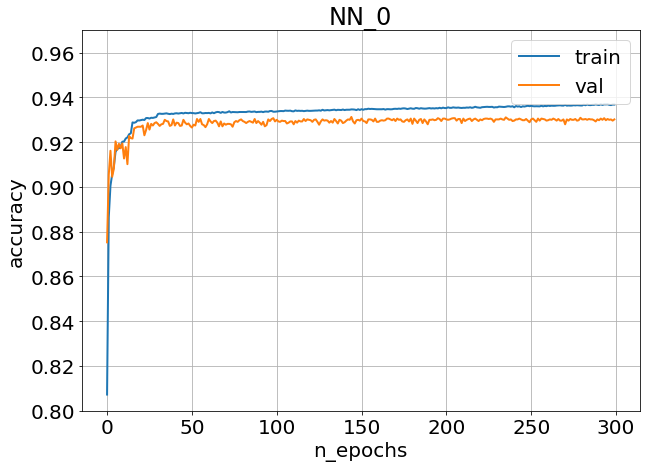

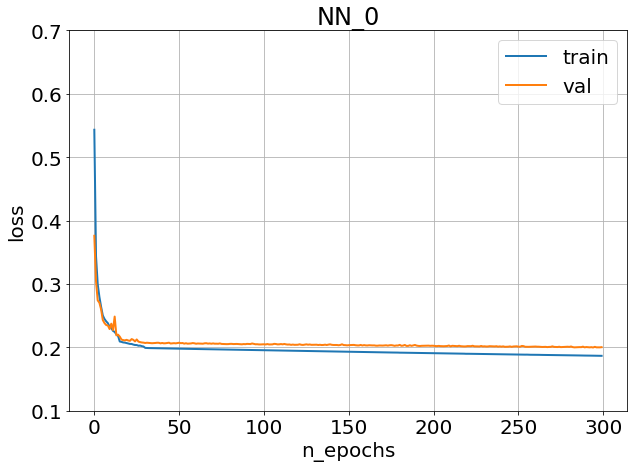

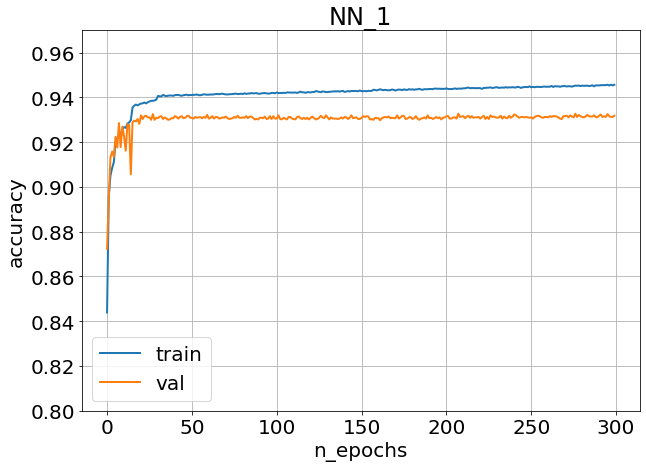

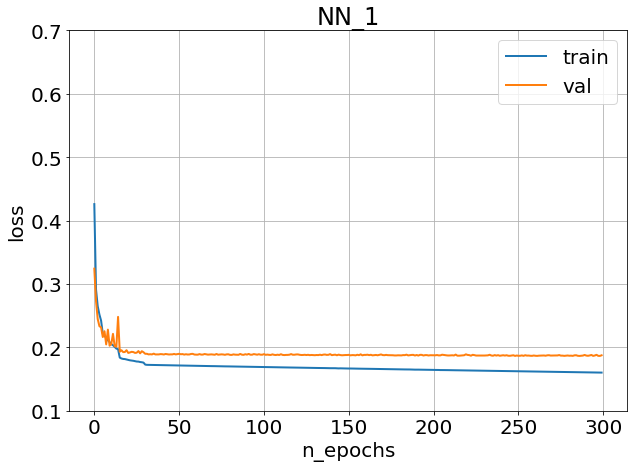

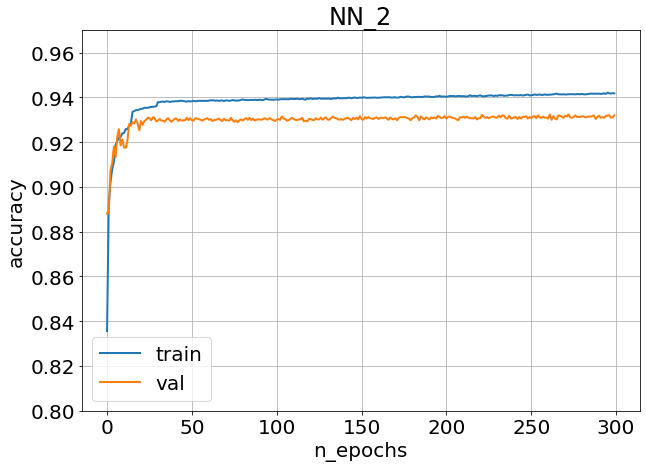

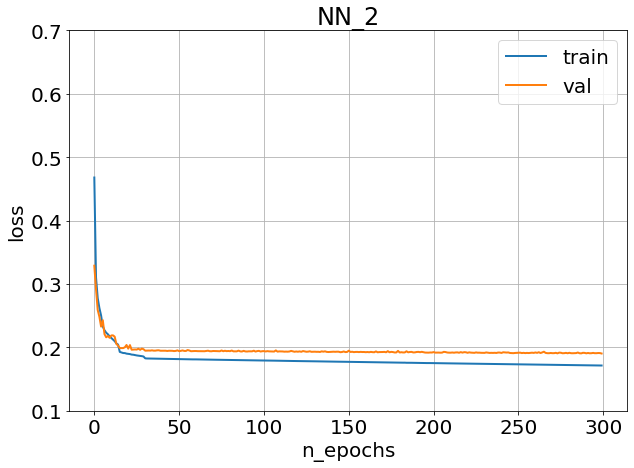

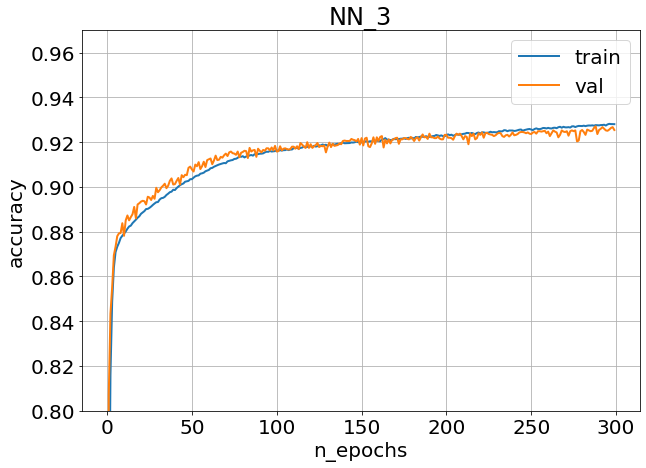

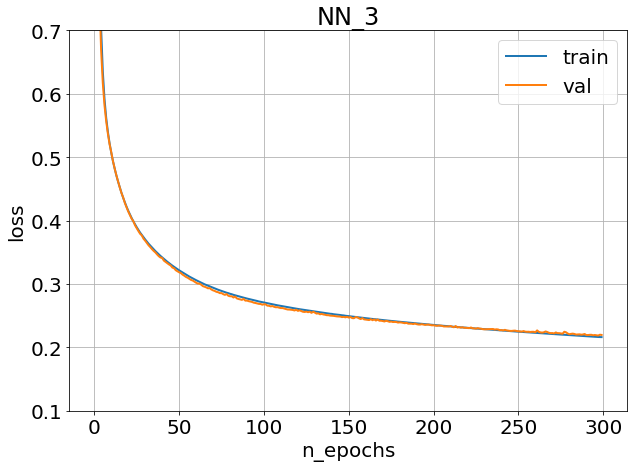

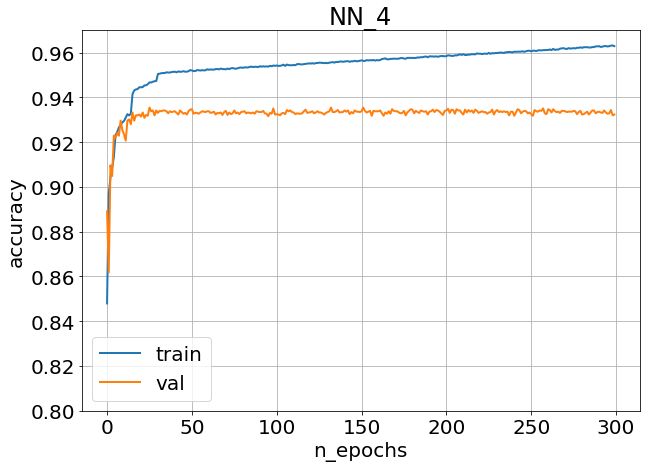

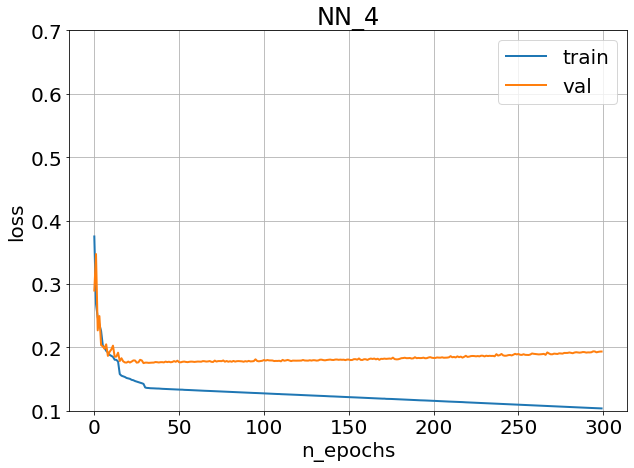

In [357]:
for model_name in ['NN_0','NN_1','NN_2','NN_3','NN_4']:
    with open('gadi_scripts/NN training/{}_history.pk'.format(model_name),'rb') as f:
        history = pickle.load(f)
    # plot learning curve
    plt.figure(figsize=(10,7))
    ax = plt.subplot()
    plt.plot(range(300), history['accuracy'],label = 'train')
    plt.plot(range(300), history['val_accuracy'],label = 'val')
    plt.legend()
    plt.title(model_name)
    plt.xlabel('n_epochs')
    ax.set_ylim(0.8,0.97)
    plt.ylabel('accuracy')
    plt.grid()
    plt.savefig('gadi_scripts/NN training/'+model_name+'_lc_accuracy.png',dpi=400)

    plt.figure(figsize=(10,7))
    ax = plt.subplot()
    plt.plot(range(300), history['loss'],label = 'train')
    plt.plot(range(300), history['val_loss'],label = 'val')
    plt.legend()
    plt.title(model_name)
    plt.xlabel('n_epochs')
    ax.set_ylim(0.1,0.7)
    plt.ylabel('loss')
    plt.grid()
    plt.savefig('gadi_scripts/NN training/'+model_name+'_lc_loss.png',dpi=400)



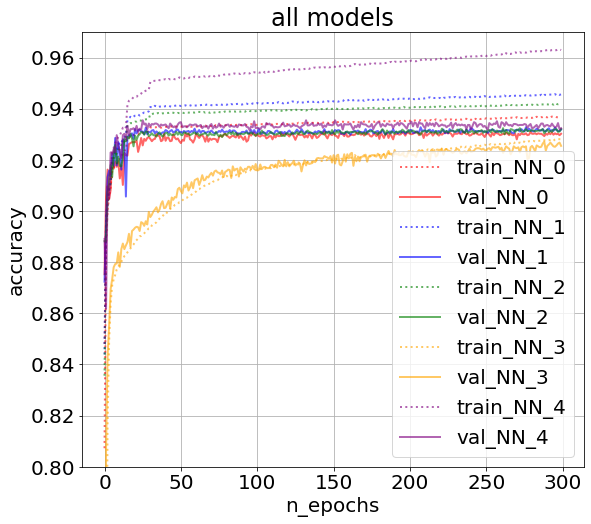

In [362]:
plt.figure(figsize=(9,8))
ax = plt.subplot()
for model_name,c in zip(['NN_0','NN_1','NN_2','NN_3','NN_4'],['r','b','g','orange','purple']):
    with open('gadi_scripts/NN training/{}_history.pk'.format(model_name),'rb') as f:
        history = pickle.load(f)
    # plot learning curve

    plt.plot(range(300), history['accuracy'],label = 'train_'+model_name,c=c,ls = ':',alpha = 0.6)
    plt.plot(range(300), history['val_accuracy'],label = 'val_'+model_name,c=c, ls = '-',alpha = 0.6)
plt.legend()
plt.title('all models')
plt.xlabel('n_epochs')
ax.set_ylim(0.8,0.97)
plt.ylabel('accuracy')
plt.grid()
plt.savefig('gadi_scripts/NN training/all_lc_accuracy.png',dpi=400)

    # plt.figure(figsize=(10,7))
    # plt.plot(range(300), history['loss'],label = 'train')
    # plt.plot(range(300), history['val_loss'],label = 'val')
    # plt.legend()
    # plt.title(model_name)
    # plt.xlabel('n_epochs')
    # plt.ylim(0.8,0.97)
    # plt.ylabel('loss')
    # plt.grid()
    # plt.savefig('gadi_scripts/NN training/'+model_name+'_lc_loss.png',dpi=400)

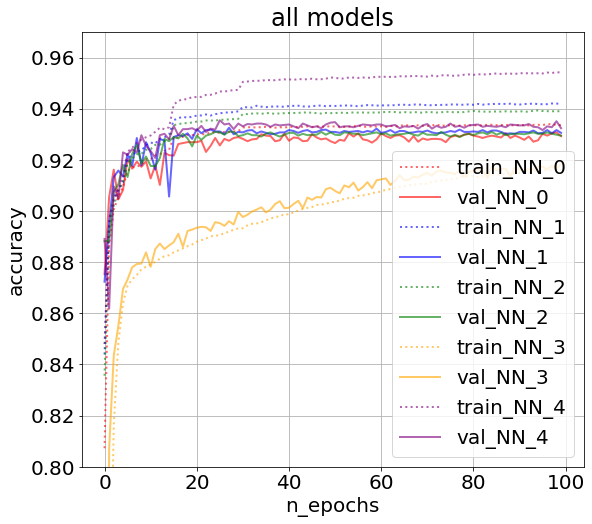

In [365]:
plt.figure(figsize=(9,8))
ax = plt.subplot()
for model_name,c in zip(['NN_0','NN_1','NN_2','NN_3','NN_4'],['r','b','g','orange','purple']):
    with open('gadi_scripts/NN training/{}_history.pk'.format(model_name),'rb') as f:
        history = pickle.load(f)
    # plot learning curve

    plt.plot(range(100), history['accuracy'][:100],label = 'train_'+model_name,c=c,ls = ':',alpha = 0.6)
    plt.plot(range(100), history['val_accuracy'][:100],label = 'val_'+model_name,c=c, ls = '-',alpha = 0.6)
plt.legend()
plt.title('all models')
plt.xlabel('n_epochs')
ax.set_ylim(0.8,0.97)
plt.ylabel('accuracy')
plt.grid()
plt.savefig('gadi_scripts/NN training/all_lc_accuracy_100.png',dpi=400)

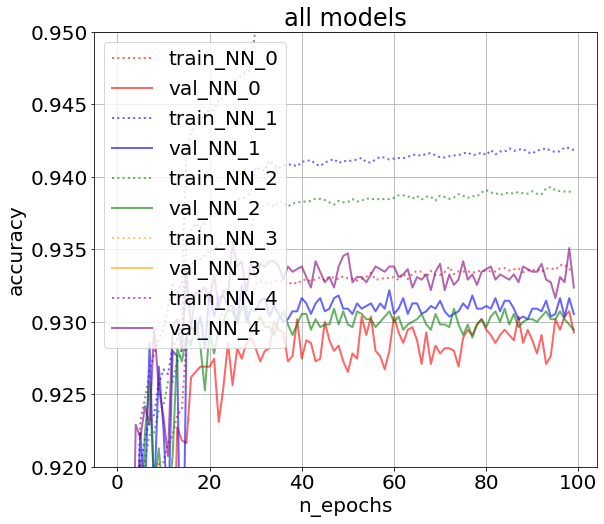

In [380]:
plt.figure(figsize=(9,8))
ax = plt.subplot()
for model_name,c in zip(['NN_0','NN_1','NN_2','NN_3','NN_4'],['r','b','g','orange','purple']):
    with open('gadi_scripts/NN training/{}_history.pk'.format(model_name),'rb') as f:
        history = pickle.load(f)
    # plot learning curve

    plt.plot(range(100), history['accuracy'][:100],label = 'train_'+model_name,c=c,ls = ':',alpha = 0.6)
    plt.plot(range(100), history['val_accuracy'][:100],label = 'val_'+model_name,c=c, ls = '-',alpha = 0.6)
plt.legend()
plt.title('all models')
plt.xlabel('n_epochs')
ax.set_ylim(0.92,0.95)
plt.ylabel('accuracy')
plt.grid()

In [339]:
import glob

['gadi_scripts/NN_descending\\NN_1e-1_history.pk',
 'gadi_scripts/NN_descending\\NN_4e-2_history.pk',
 'gadi_scripts/NN_descending\\NN_7e-2_history.pk',
 'gadi_scripts/NN_descending\\NN_cpu_history.pk']

In [358]:
mnames = [s.split('\\')[1].split('_history')[0] for s in glob.glob('gadi_scripts/NN_descending/NN_*history.pk')][:-1]

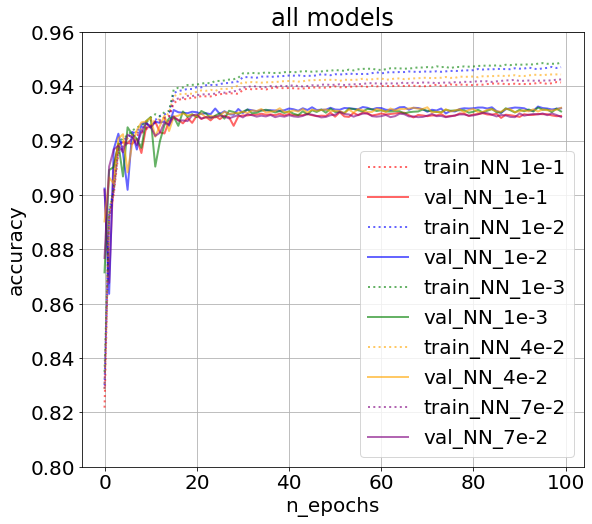

In [364]:
plt.figure(figsize=(9,8))
ax = plt.subplot()
for model_name,c in zip(mnames,['r','b','g','orange','purple']):
    with open('gadi_scripts/NN_descending/{}_history.pk'.format(model_name),'rb') as f:
        history = pickle.load(f)
    # plot learning curve

    plt.plot(range(100), history['accuracy'][:100],label = 'train_'+model_name,c=c,ls = ':',alpha = 0.6)
    plt.plot(range(100), history['val_accuracy'][:100],label = 'val_'+model_name,c=c, ls = '-',alpha = 0.6)
plt.legend()
plt.title('all models')
plt.xlabel('n_epochs')
ax.set_ylim(0.80,0.96)
plt.ylabel('accuracy')
plt.grid()
plt.savefig('gadi_scripts/NN_descending/all_lc_accuracy.png',dpi=400)

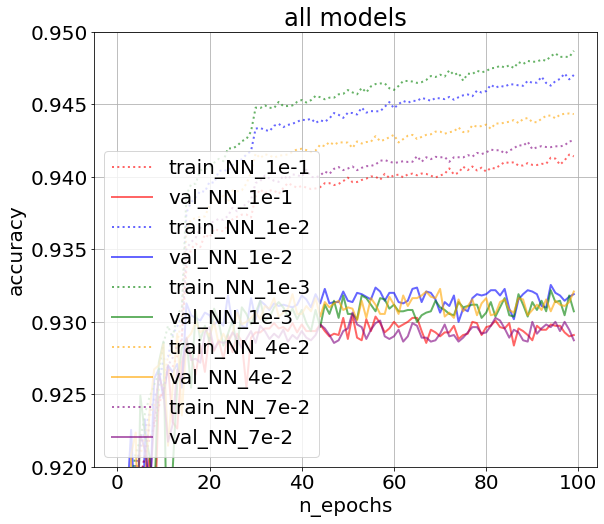

In [372]:
plt.figure(figsize=(9,8))
ax = plt.subplot()
for model_name,c in zip(mnames,['r','b','g','orange','purple']):
    with open('gadi_scripts/NN_descending/{}_history.pk'.format(model_name),'rb') as f:
        history = pickle.load(f)
    # plot learning curve

    plt.plot(range(100), history['accuracy'][:100],label = 'train_'+model_name,c=c,ls = ':',alpha = 0.6)
    plt.plot(range(100), history['val_accuracy'][:100],label = 'val_'+model_name,c=c, ls = '-',alpha = 0.6)
plt.legend(loc='lower left')
plt.title('all models')
plt.xlabel('n_epochs')
ax.set_ylim(0.92,0.95)
plt.ylabel('accuracy')
plt.grid()

In [ ]:
## dropouts

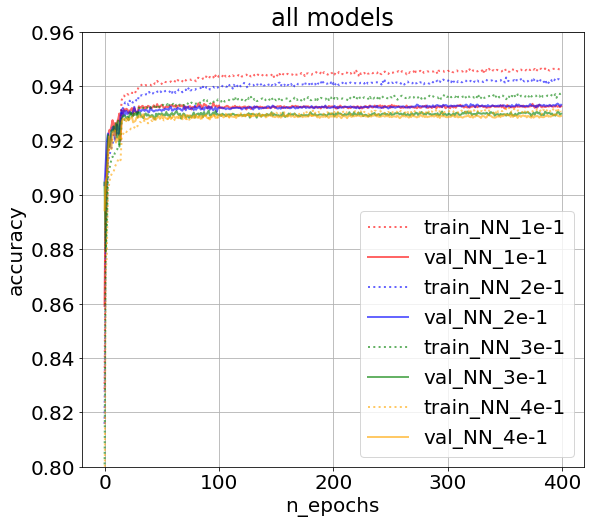

In [377]:
mnames = [s.split('\\')[1].split('_history')[0] for s in glob.glob('gadi_scripts/NN_descending_dropouts/NN_*history.pk')][:-1]
plt.figure(figsize=(9,8))
ax = plt.subplot()
for model_name,c in zip(mnames,['r','b','g','orange','purple']):
    with open('gadi_scripts/NN_descending_dropouts/{}_history.pk'.format(model_name),'rb') as f:
        history = pickle.load(f)
    # plot learning curve

    plt.plot(range(400), history['accuracy'][:],label = 'train_'+model_name,c=c,ls = ':',alpha = 0.6)
    plt.plot(range(400), history['val_accuracy'][:],label = 'val_'+model_name,c=c, ls = '-',alpha = 0.6)
plt.legend()
plt.title('all models')
plt.xlabel('n_epochs')
ax.set_ylim(0.80,0.96)
plt.ylabel('accuracy')
plt.grid()
plt.savefig('gadi_scripts/NN_descending_dropouts/all_lc_accuracy.png',dpi=400)

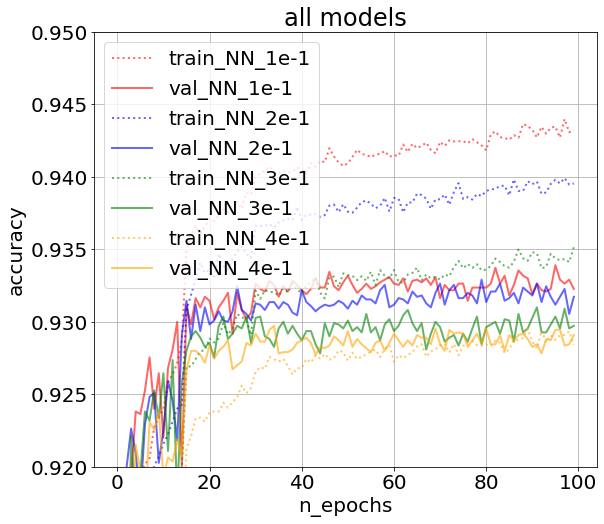

In [381]:
plt.figure(figsize=(9,8))
ax = plt.subplot()
for model_name,c in zip(mnames,['r','b','g','orange','purple']):
    with open('gadi_scripts/NN_descending_dropouts/{}_history.pk'.format(model_name),'rb') as f:
        history = pickle.load(f)
    # plot learning curve

    plt.plot(range(100), history['accuracy'][:100],label = 'train_'+model_name,c=c,ls = ':',alpha = 0.6)
    plt.plot(range(100), history['val_accuracy'][:100],label = 'val_'+model_name,c=c, ls = '-',alpha = 0.6)
plt.legend()
plt.title('all models')
plt.xlabel('n_epochs')
ax.set_ylim(0.92,0.95)
plt.ylabel('accuracy')
plt.grid()

In [161]:
## get the simulation index for samples in train and val 

(110000, 625)

In [168]:
X_train_i, X_val_i, _ , _ = train_test_split(np.array(range(110000)),y[:], test_size=0.05,random_state=666,stratify=y[:])

In [169]:
X_train_i

array([107151,   5493,   8126, ...,  10555, 103541,  16663])

In [170]:
X_val_i

array([ 8292, 17058, 64238, ..., 62157, 39547, 84808])

In [143]:

X_train, X_val, y_train, y_val = train_test_split(X[:,:],y[:], test_size=0.05,random_state=666,stratify=y[:])

In [144]:
with open('gadi_scripts/NN training/NN_1_predictions','rb') as f:
    y_train_pred, y_test_pred = pickle.load(f)

In [ ]:
## inspecting misclassified training samples

In [156]:
train_errors_i = np.where(y_train_pred.argmax(axis=1) != y_train)

In [158]:
y_train[train_errors_i]

array([2, 0, 2, ..., 1, 2, 1])

In [157]:
y_train_pred[train_errors_i]
# we can see that other classes also have decent probability scores

array([[0.37939167, 0.361094  , 0.25951427],
       [0.11820801, 0.43150213, 0.4502899 ],
       [0.885378  , 0.021959  , 0.09266291],
       ...,
       [0.39640528, 0.23406953, 0.36952522],
       [0.17051068, 0.5634291 , 0.2660602 ],
       [0.56151927, 0.4261831 , 0.01229762]], dtype=float32)

In [238]:
simulation_indices_error = X_train_i[train_errors_i]

In [235]:
def get_simu_summary(indices):
    result = []
    for i in indices:
        treef = 'data_input/trees/t_{}.nwk'.format(i)
        logf = 'data_input/trees/t_{}.nwk.log'.format(i)

        with open(treef,'r') as f:
            tree = f.read()
        info = {}
        sp = tree.split(',')
        info['simu_index'] = i
        info[sp[0][1]] = float(sp[0][3:])
        info[sp[2][1]] = float(sp[2][3:])
        info[sp[1][0]] = float(sp[1][2:])
        info[sp[3][0]] = float(sp[3].split(')')[0][2:])
        info['int_b'] = float(sp[3].split(')')[1][1:])
        top = ''.join(sorted(sp[0][1] + sp[1][0]))
        if 'A' not in top:
            for other in ('B','C','D'):
                if other not in top:
                    top = 'A' + other
                    break
        info['top'] = top
        result.append(info)
    df = pd.DataFrame(result)
    df.set_index('simu_index',inplace=True)
    df.columns = [  'A','B', 'C','D', 'int_b', 'top']    
    return df

    
    


In [239]:
train_error_settings = get_simu_summary(simulation_indices_error)
train_error_settings

,A,B,C,D,int_b,top
simu_index,,,,,,
45311,0.0022,0.0031,0.0030,0.0457,0.0021,AD
38457,0.1121,0.0072,0.0172,0.0619,0.0022,AB
15937,0.0181,0.2184,0.0140,0.1473,0.0070,AD
99078,0.0035,0.1148,0.0242,0.2957,0.0005,AC
67289,0.0057,0.0618,0.0149,0.1106,0.0004,AB
...,...,...,...,...,...,...
102340,0.2240,0.0207,0.1306,0.0088,0.0006,AB
24015,0.0161,0.0053,0.0922,0.0474,0.0019,AC
3976,0.0067,0.0005,0.0472,0.0299,0.0030,AC


In [240]:
X_train_i[train_errors_i]

array([45311, 38457, 15937, ...,  3976, 95702, 16663])

In [241]:
mask = np.ones(len(X_train_i),dtype=bool)
mask[train_errors_i] = False
simulation_indices_accurate = X_train_i[mask]

In [242]:
train_accurate_settings = get_simu_summary(simulation_indices_accurate)
train_accurate_settings

,A,B,C,D,int_b,top
simu_index,,,,,,
107151,0.0047,0.0314,0.0725,0.0031,0.1280,AC
5493,0.0500,0.0060,0.0119,0.0404,0.0143,AB
8126,0.0215,0.0145,0.0056,0.0621,0.0198,AC
83815,0.0362,0.0452,0.0124,0.0450,0.0034,AC
97118,0.0032,0.0047,0.1625,0.0035,0.0787,AC
...,...,...,...,...,...,...
108279,0.0125,0.0022,0.0073,0.0028,0.0069,AD
38580,0.0085,0.0530,0.1071,0.0533,0.0233,AC
14338,0.1042,0.0060,0.0813,0.0114,0.0046,AB


In [327]:
train_accurate_settings.shape

(98768, 6)

In [330]:
500 * (98768 / 5732)

8615.49197487788

In [328]:
train_error_settings.shape

(5732, 6)

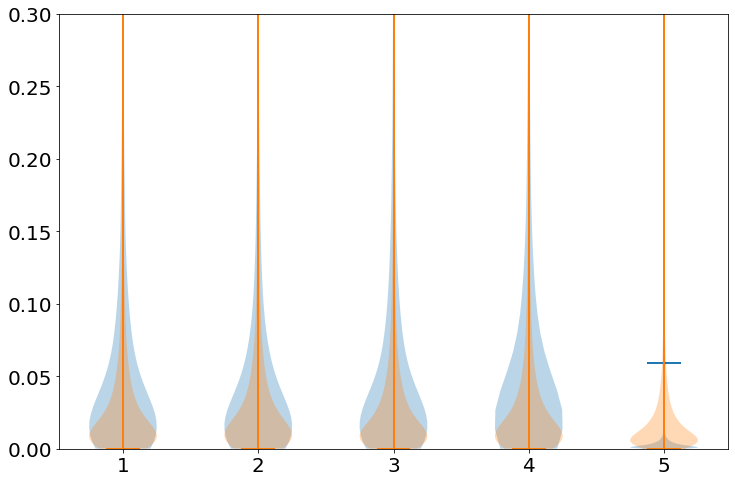

In [331]:
ax = plt.axes()
ax.violinplot(train_error_settings.iloc[:,:-1].to_numpy(),points=500)
ax.violinplot(train_accurate_settings.iloc[:,:-1].to_numpy(),points=8615)
ax.set_ylim(0,0.3)
plt.show()

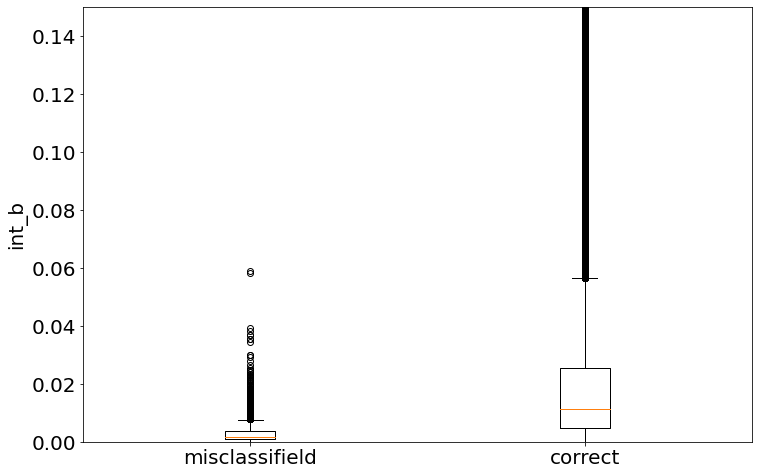

In [324]:
column_i = 4
ax = plt.axes()
ax.boxplot([train_error_settings.iloc[:,column_i].to_numpy(),
            train_accurate_settings.iloc[:,column_i].to_numpy()],labels=['misclassifield','correct'])
ax.set_ylim(0,0.15)
ax.set_ylabel(train_accurate_settings.columns[column_i])
plt.show()

In [322]:
train_error_settings

,A,B,C,D,int_b,top
simu_index,,,,,,
45311,0.0022,0.0031,0.0030,0.0457,0.0021,AD
38457,0.1121,0.0072,0.0172,0.0619,0.0022,AB
15937,0.0181,0.2184,0.0140,0.1473,0.0070,AD
99078,0.0035,0.1148,0.0242,0.2957,0.0005,AC
67289,0.0057,0.0618,0.0149,0.1106,0.0004,AB
...,...,...,...,...,...,...
102340,0.2240,0.0207,0.1306,0.0088,0.0006,AB
24015,0.0161,0.0053,0.0922,0.0474,0.0019,AC
3976,0.0067,0.0005,0.0472,0.0299,0.0030,AC


In [ ]:
## misclassified samples tend to have shorter internal branches 

In [ ]:
## todo: modify function to get info from log file 
def get_simu_summary(indices):
    result = []
    for i in indices:
        treef = 'data_input/trees/t_{}.nwk'.format(i)
        logf = 'data_input/trees/t_{}.nwk.log'.format(i)

        with open(treef,'r') as f:
            tree = f.read()
        info = {}
        sp = tree.split(',')
        info['simu_index'] = i
        info[sp[0][1]] = float(sp[0][3:])
        info[sp[2][1]] = float(sp[2][3:])
        info[sp[1][0]] = float(sp[1][2:])
        info[sp[3][0]] = float(sp[3].split(')')[0][2:])
        info['int_b'] = float(sp[3].split(')')[1][1:])
        top = ''.join(sorted(sp[0][1] + sp[1][0]))
        if 'A' not in top:
            for other in ('B','C','D'):
                if other not in top:
                    top = 'A' + other
                    break
        info['top'] = top
        result.append(info)
    df = pd.DataFrame(result)
    df.set_index('simu_index',inplace=True)
    df.columns = [  'A','B', 'C','D', 'int_b', 'top']    
    return df

In [136]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [137]:
pca = PCA(n_components=100, copy=False, random_state=666)
reduced = pca.fit_transform(X_scaled)

KeyboardInterrupt: 

<BarContainer object of 40 artists>

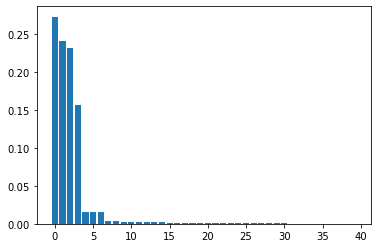

In [ ]:
plt.bar(range(40),pca.explained_variance_ratio_[:40])

In [56]:
np.abs(pca.components_).max(axis=1)[:4]

array([0.83326558, 0.90196004, 0.93258321, 0.90830845])

In [57]:
np.abs(pca.components_).argmax(axis=1)[:4]

array([  0, 468, 312, 156], dtype=int64)

In [78]:
_ = [print(get_pattern(i)) for i in np.abs(pca.components_[:10]).argmax(axis=1)]

A
A
A
A

T
T
T
T

G
G
G
G

C
C
C
C

A
A
A
-

A
A
-
A

-
A
A
A

-
-
-
-

A
A
G
A

T
C
T
T



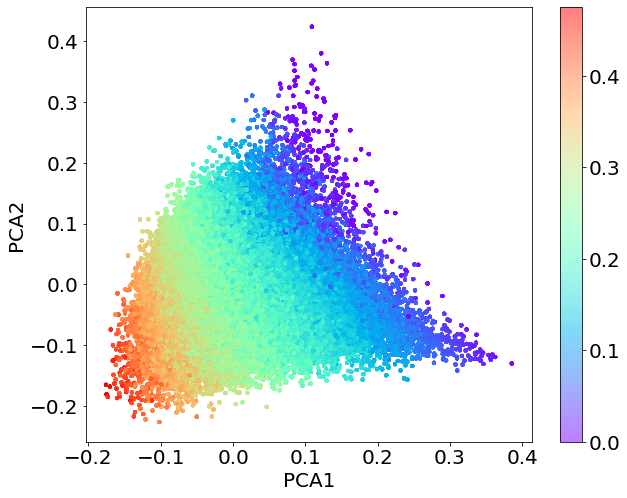

In [75]:
plt.figure(figsize=(10,8))
plt.scatter(reduced[:,0],reduced[:,1],c = X_scaled[:,0],cmap='rainbow',alpha=0.5)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.colorbar()

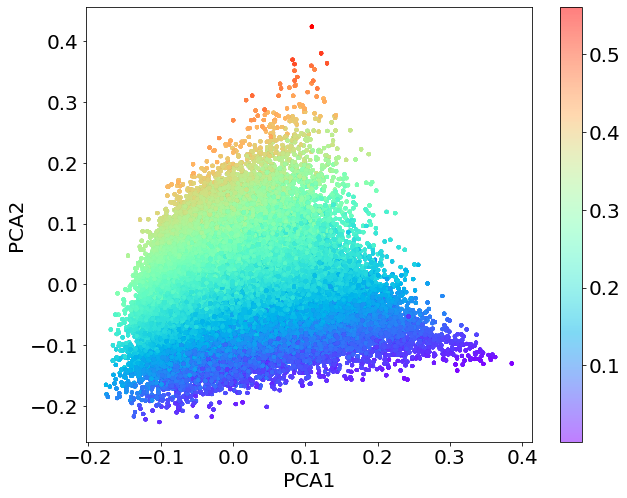

In [73]:
plt.figure(figsize=(10,8))
plt.scatter(reduced[:,0],reduced[:,1],c = X_scaled[:,468],cmap='rainbow',alpha=0.5)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.colorbar()
plt.show()

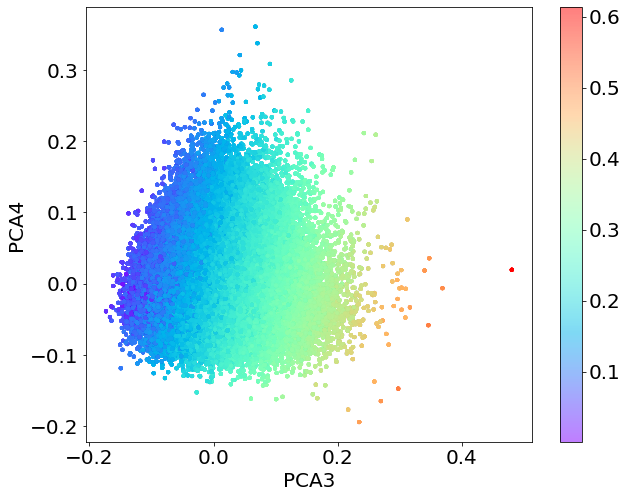

In [76]:
plt.figure(figsize=(10,8))
plt.scatter(reduced[:,2],reduced[:,3],c = X_scaled[:,312],cmap='rainbow',alpha=0.5)
plt.xlabel('PCA3')
plt.ylabel('PCA4')
plt.colorbar()
plt.show()

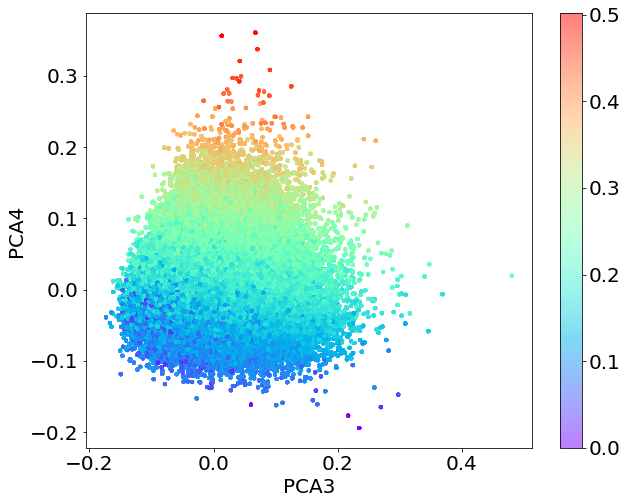

In [77]:
plt.figure(figsize=(10,8))
plt.scatter(reduced[:,2],reduced[:,3],c = X_scaled[:,156],cmap='rainbow',alpha=0.5)
plt.xlabel('PCA3')
plt.ylabel('PCA4')
plt.colorbar()
plt.show()

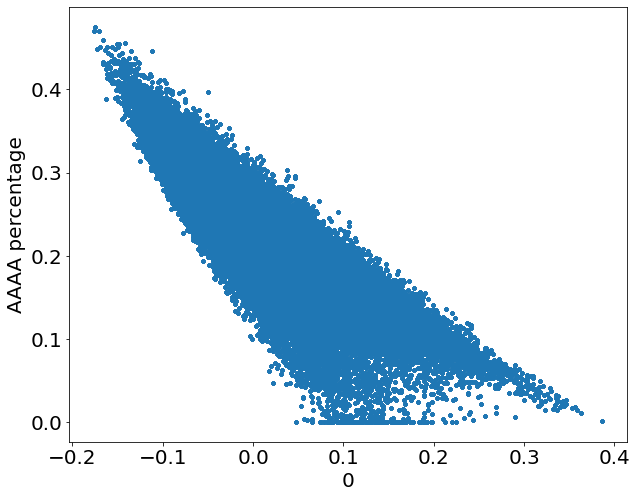

In [87]:
plt.figure(figsize=(10,8))
plt.scatter(reduced[:,0], X_scaled[:,0],alpha=0.5)
plt.xlabel('0')
plt.ylabel('AAAA percentage')
plt.show()

In [88]:
from sklearn.manifold import TSNE

In [103]:
tsne = TSNE(n_components=2, verbose=1, perplexity=200)
tsne_data = tsne.fit_transform(reduced[:100000,:])



c:\Users\zhuang\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
c:\Users\zhuang\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


[t-SNE] Computing 601 nearest neighbors...
[t-SNE] Indexed 100000 samples in 0.023s...
[t-SNE] Computed neighbors for 100000 samples in 10.490s...
[t-SNE] Computed conditional probabilities for sample 1000 / 100000
[t-SNE] Computed conditional probabilities for sample 2000 / 100000
[t-SNE] Computed conditional probabilities for sample 3000 / 100000
[t-SNE] Computed conditional probabilities for sample 4000 / 100000
[t-SNE] Computed conditional probabilities for sample 5000 / 100000
[t-SNE] Computed conditional probabilities for sample 6000 / 100000
[t-SNE] Computed conditional probabilities for sample 7000 / 100000
[t-SNE] Computed conditional probabilities for sample 8000 / 100000
[t-SNE] Computed conditional probabilities for sample 9000 / 100000
[t-SNE] Computed conditional probabilities for sample 10000 / 100000
[t-SNE] Computed conditional probabilities for sample 11000 / 100000
[t-SNE] Computed conditional probabilities for sample 12000 / 100000
[t-SNE] Computed conditional proba

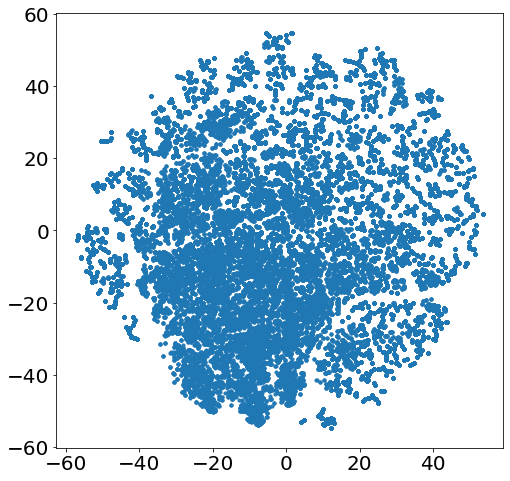

In [107]:
plt.figure(figsize=(8,8))
plt.scatter(tsne_data[:,0],tsne_data[:,1],alpha=0.7)
plt.show()

In [28]:
list(tf.data.Dataset.from_tensor_slices ((X_scaled[:10,:6],y_numerical[:10])).as_numpy_iterator())

[(array([0.22651934, 0.        , 0.00184162, 0.        , 0.        ,
         0.        ]),
  2),
 (array([0.22651934, 0.        , 0.01473297, 0.        , 0.        ,
         0.        ]),
  1),
 (array([0.22651934, 0.        , 0.00184162, 0.        , 0.        ,
         0.        ]),
  2),
 (array([0.22651934, 0.        , 0.00736648, 0.00184162, 0.00184162,
         0.        ]),
  1),
 (array([0.22651934, 0.        , 0.01473297, 0.        , 0.        ,
         0.        ]),
  0),
 (array([0.22651934, 0.        , 0.00736648, 0.00184162, 0.00184162,
         0.        ]),
  0),
 (array([0.22651934, 0.        , 0.00184162, 0.        , 0.        ,
         0.        ]),
  1),
 (array([0.22651934, 0.        , 0.01473297, 0.        , 0.        ,
         0.        ]),
  2),
 (array([0.22651934, 0.        , 0.00184162, 0.        , 0.        ,
         0.        ]),
  0),
 (array([0.22651934, 0.        , 0.03130755, 0.00736648, 0.01473297,
         0.        ]),
  0)]

In [16]:
lr = LogisticRegression(penalty='none' ,solver='saga',n_jobs=-3,random_state=666,max_iter=50000)
lr.fit(X_scaled[sample_i,:],y[sample_i])

LogisticRegression(max_iter=50000, n_jobs=-3, penalty='none', random_state=666,
                   solver='saga')

In [17]:
lr.score(X_scaled[sample_i,:],y[sample_i])

0.90621

In [18]:
lr.score(X_scaled[val_i,:],y[val_i])

0.901

In [26]:
lr.score(X_scaled[sample_i,:],y[sample_i])

0.90693

In [27]:
lr.score(X_scaled[val_i,:],y[val_i])

0.904

In [35]:
lr.classes_

array(['AB', 'AC', 'AD'], dtype='<U2')

In [56]:
(lr.coef_[0] > 1).sum()

322

In [54]:
lr.coef_[0][feature_names.index('A\nA\nA\nA\n')]

0.15675086777665376

In [60]:
lr.coef_[2][feature_names.index('T\nT\nT\nT\n')]

0.014375873851454926

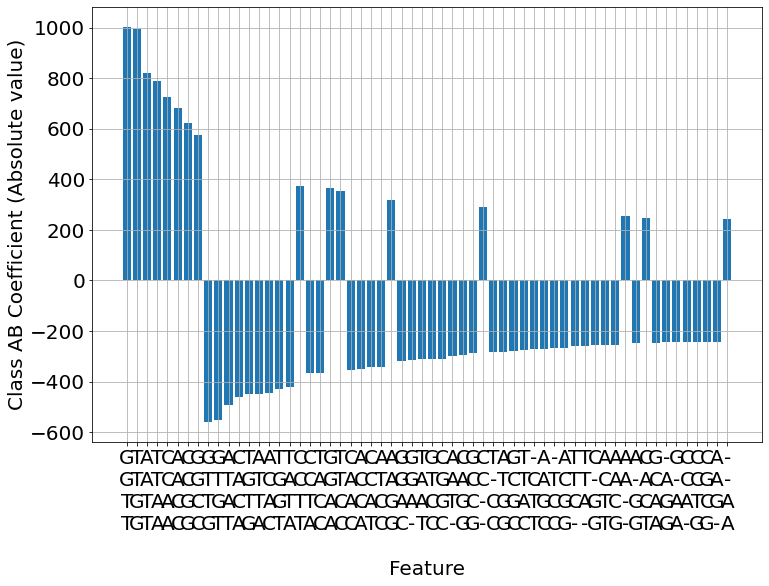

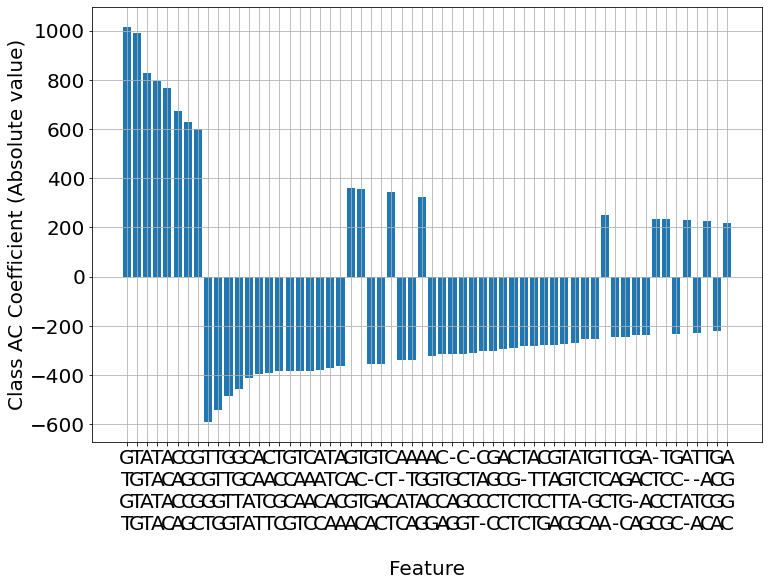

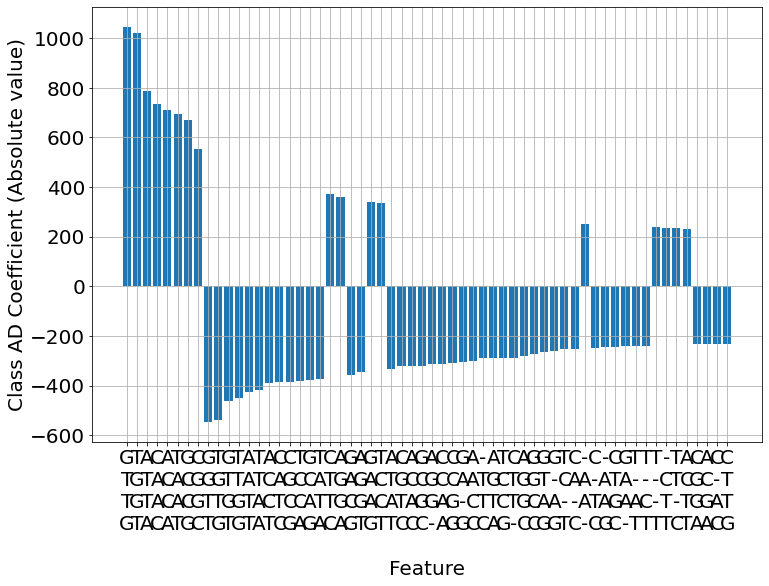

In [48]:
feature_profile_multi(lr.coef_,feature_names,n_features=60,class_labels=['AB', 'AC', 'AD'],absolute=False)

every class is essentially equivalent, and we have symmetric features, the feature profiel should look very similar 

In [12]:
lr_idf = LogisticRegression(C = 83,solver='saga',n_jobs=-3,random_state=666,max_iter=50000)
lr_idf.fit(X_idf[sample_i,:],y[sample_i])

LogisticRegression(C=83, max_iter=50000, n_jobs=-3, random_state=666,
                   solver='saga')

In [25]:
lr_idf.C_

NameError: name 'lr_idf' is not defined

In [ ]:
lr_idf.scores_['AC'].mean(axis=0)

array([0.8918, 0.8919, 0.8926, 0.8923, 0.8925, 0.8933, 0.8934, 0.8933,
       0.8933, 0.893 ])

In [13]:
lr_idf.score(X_idf[sample_i,:],y[sample_i])

0.90841

In [14]:
lr_idf.score(X_idf[val_i,:],y[val_i])

0.902

In [36]:
def plot_learning_curve(model, features, labels, c = 'tab:blue',save_path = None,ylim = 0.92):
    sampling = np.linspace(0.05,1.0,20)
    sizes,train_scores,test_scores = learning_curve(model, features,labels, train_sizes=sampling,n_jobs=-1,cv=7)
    train_std = np.std(train_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    plt.figure()
    plt.plot(sizes, train_mean,marker='^',label='train',alpha=1,c = c,ms = 6,ls = ':')
    plt.plot(sizes, test_mean,marker='v',label='val',alpha=1,c=c,ms = 6,ls='--')
    plt.fill_between(sizes, train_mean-train_std, train_mean+train_std,color=c,alpha =0.1)
    plt.fill_between(sizes, test_mean-test_std, test_mean+test_std,color=c,alpha =0.1)
    plt.grid()
    # plt.ylim((ylim,1.0))
    plt.xlabel('$n\_samples$')
    plt.ylabel('Score')
    plt.legend(loc = 'lower right')
    if save_path != None:
        plt.savefig(save_path,dpi=500)
    plt.show()

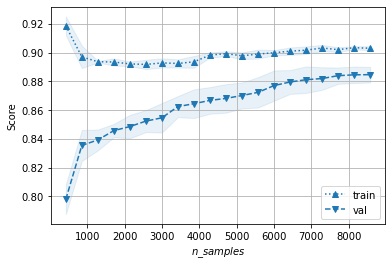

In [37]:
clf = LogisticRegression(penalty='none' ,solver='saga',random_state=666,max_iter=50000)
plot_learning_curve(clf, X_scaled[sample_i,:],y[sample_i])

In [32]:
lr = LogisticRegression(penalty='none' ,solver='saga',n_jobs=-3,random_state=666,max_iter=10000)
lr.fit(X[sample_i,:],y[sample_i])

LogisticRegression(max_iter=10000, n_jobs=-3, penalty='none', random_state=666,
                   solver='saga')

In [33]:
lr.score(X[sample_i,:],y[sample_i])

0.9019

In [34]:
lr.score(X_scaled[val_i,:],y[val_i])

0.41

In [2]:
with open('data_encoded_scaled_new.pk','rb') as f:
    X,y = pickle.load(f)

X_train, X_val = (X[:-24000,:], X[-24000:,:])
y_train, y_val = (y[:-24000], y[-24000:])
del X, y

In [3]:
tops = ['AB','AC','AD']
species = ['A','B','C','D']
def revert_label(i, top):
    order = P4[i]
    sib1 = order[tops.index(top)+1] 
    sib2 = order[0]
    if 0 in (sib2,sib1):
        topr = sorted(species[sib1]+species[sib2])
    else:
        topr = sorted([species[num] for num in range(4) if num not in (sib2,sib1)])
    return ''.join(topr)

In [22]:
y_train[:24]

array([2, 1, 2, 1, 0, 0, 1, 2, 0, 0, 2, 1, 1, 2, 0, 0, 2, 1, 0, 0, 1, 2,
       1, 2])

In [38]:
revert_label(2,'AD')

'AD'

In [4]:

def decay(epoch):
  if epoch < 5:
    return 5e-4
  elif epoch >= 5 and epoch < 15:
    return 1e-4
  else:
    return 1e-5
  

model = keras.Sequential()
model.add(keras.layers.Dense(625,'relu'))
model.add(keras.layers.Dense(625,'relu'))
model.add(keras.layers.Dense(3,'softmax',kernel_regularizer=keras.regularizers.L2(0.001)))
model.compile(optimizer = keras.optimizers.Adam(1e-5,epsilon=1e-8),loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])   

# Create a callback that saves the model's weights

callbacks = [keras.callbacks.LearningRateScheduler(decay)]
# train model, save model
history = model.fit(X_train,y_train,epochs=50,verbose=1,batch_size = 128, validation_data = (X_val,y_val),callbacks=callbacks)

model.save('test_new_data')

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.